In [17]:
import glob

from tensordict.tensordict import TensorDict

files = glob.glob("/scratch/gclyne/memmap_filled_in_new/*")

In [19]:
import torch

for file in files:
    # print(file)
    exp = file.split("/")[-1].split(".")[0].split("_")[1]
    # print(exp)
    data_dict = TensorDict.load_memmap(file)

    if exp == "ssp534-over":
        data = torch.load(
            f"/scratch/gclyne/reference_data/aerosol_{exp}.pt",
            weights_only=False,
        )[:, 12 * 25 :]
        dummies = torch.zeros(6, 2, 144, 144)

        data = torch.concatenate([data, dummies], axis=1)
        data_dict["spatial_forcings"][3:9] = data
        # patch ozone
        data = torch.load(f"/scratch/gclyne/reference_data/ozone_{exp}.pt")[
            (12 * 25) :
        ]  # bug in saved file, need -2 offset
        print("ozone", data.shape)
        dummies = torch.zeros(2, 66, 144, 144)
        data = torch.concatenate([data, dummies])
        data_dict["spatial_forcings"][9:15] = data[:, :6].swapdims(0, 1)
        spatial_gases = ["methane", "carbon", "nitrous"]
        for i, gas in enumerate(spatial_gases):
            ghg_data = torch.load(
                f"/scratch/gclyne/reference_data/processed_spatial_monthly_ghg_forcings/{gas}_ssp534.pt"
            )[(12 * 25) :]
            print(ghg_data.shape)
            dummies = torch.zeros(2, 144, 144)
            ghg_data = torch.cat((ghg_data, dummies), dim=0)
            data_dict["spatial_forcings"][i] = ghg_data
        solar_forcings = torch.load(
            "/scratch/gclyne/reference_data/solar_forcings_monthly_interpolated.pt"
        )  # need to generate this first
        for ssi_band_index in range(6):
            ssi = solar_forcings[((12 * 165) + (12 * 25)) :]
            print(ssi.shape)
            dummies = torch.zeros(2, 6)
            ssi = torch.cat((ssi, dummies), dim=0)
            data_dict["non_spatial_forcings"][ssi_band_index] = ssi[:, ssi_band_index]
            print(data_dict["non_spatial_forcings"].shape)
        # break

    else:
        continue
    # break

ozone torch.Size([732, 66, 144, 144])
torch.Size([732, 144, 144])
torch.Size([732, 144, 144])
torch.Size([732, 144, 144])
torch.Size([732, 6])
torch.Size([6, 734])
torch.Size([732, 6])
torch.Size([6, 734])
torch.Size([732, 6])
torch.Size([6, 734])
torch.Size([732, 6])
torch.Size([6, 734])
torch.Size([732, 6])
torch.Size([6, 734])
torch.Size([732, 6])
torch.Size([6, 734])


In [20]:
TensorDict.save(data_dict, file)

TensorDict(
    fields={
        lev: MemoryMappedTensor(shape=torch.Size([1, 734, 10, 144, 144]), device=cpu, dtype=torch.float32, is_shared=True),
        level: MemoryMappedTensor(shape=torch.Size([5, 734, 17, 144, 144]), device=cpu, dtype=torch.float32, is_shared=True),
        non_spatial_forcings: MemoryMappedTensor(shape=torch.Size([6, 734]), device=cpu, dtype=torch.float32, is_shared=True),
        spatial_forcings: MemoryMappedTensor(shape=torch.Size([15, 734, 144, 144]), device=cpu, dtype=torch.float32, is_shared=True),
        surface: MemoryMappedTensor(shape=torch.Size([8, 734, 144, 144]), device=cpu, dtype=torch.float32, is_shared=True),
        time: NonTensorData(data=['2040-01-16T12:00:0  ...  12:00:00.000000000'], batch_size=torch.Size([]), device=cpu)},
    batch_size=torch.Size([]),
    device=cpu,
    is_shared=False)

In [18]:
print(file)

/scratch/gclyne/memmap_filled_in/r1i1p1f1_ssp534-over_interpolation.memmap


In [1]:
import torch
from tensordict.tensordict import TensorDict

In [51]:
data = torch.load("/scratch/gclyne/reference_data/aerosol_ssp434.pt")
data_one = TensorDict.load_memmap(
    "/scratch/gclyne/memmap_filled_in/r1i1p1f1_ssp434_interpolation.memmap"
)
data_two = TensorDict.load_memmap(
    "/scratch/gclyne/memmap_filled_in/r1i1p1f1_ssp534-over_interpolation.memmap"
)

data1 = torch.load("/scratch/gclyne/reference_data/aerosol_ssp534-over.pt")

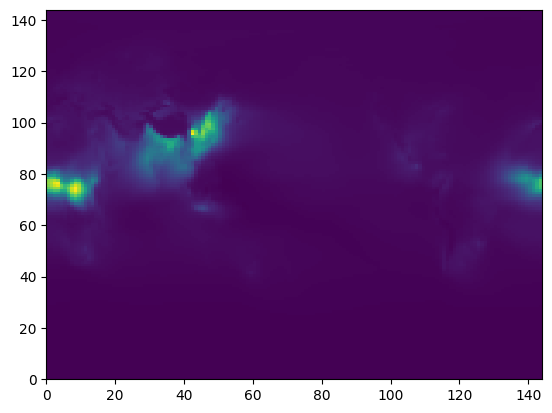

In [76]:
plt.pcolormesh(data[1, 0])

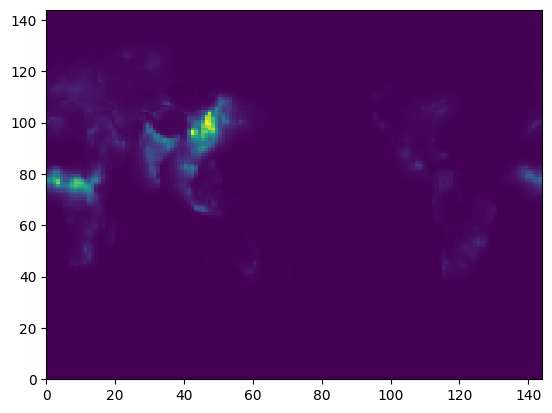

In [77]:
plt.pcolormesh(data_one["spatial_forcings"][3, 0])

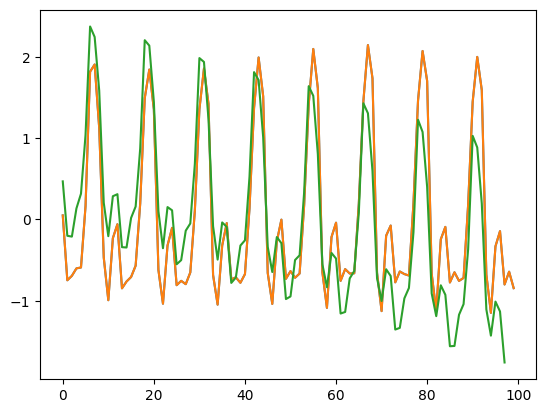

In [81]:
import matplotlib.pyplot as plt

plt.plot(
    (data[0, :100].nanmean(axis=(-1, -2)) - data[0, :100].nanmean(axis=(-1, -2)).mean())
    / data[0, :100].nanmean(axis=(-1, -2)).std()
)
# plt.plot((data_one['surface'][0,:100].nanmean(axis=(-1,-2)) - data_one['surface'][0,25*12:35*12].nanmean(axis=(-1,-2)).mean()) / data_one['surface'][0,25*12:35*12].nanmean(axis=(-1,-2)).std())
plt.plot(
    (
        data_one["spatial_forcings"][3, :100].nanmean(axis=(-1, -2))
        - data_one["spatial_forcings"][3, :100].nanmean(axis=(-1, -2)).mean()
    )
    / data_one["spatial_forcings"][3, :100].nanmean(axis=(-1, -2)).std()
)
plt.plot(
    (
        data_two["spatial_forcings"][3, 2:100].nanmean(axis=(-1, -2))
        - data_two["spatial_forcings"][3, 2:100].nanmean(axis=(-1, -2)).mean()
    )
    / data_two["spatial_forcings"][3, 2:100].nanmean(axis=(-1, -2)).std()
)
# plt.plot((data_two['surface'][0,25*12:35*12].nanmean(axis=(-1,-2)) - data_two['surface'][0,25*12:35*12].nanmean(axis=(-1,-2)).mean()) / data_two['surface'][0,25*12:35*12].nanmean(axis=(-1,-2)).std())

In [4]:
ozone = data["ozone"]

In [11]:
data["spatial_forcings"][0].nanmean(axis=(-1, -2))

tensor([1845.8270, 1844.9937, 1844.0229,  ..., 1690.0602, 1690.5388,
        1690.5903])

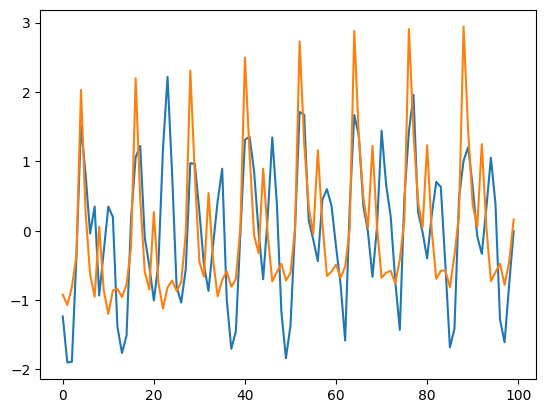

In [27]:
import matplotlib.pyplot as plt

plt.plot(
    (ozone.mean(axis=(-1, -2))[:100, 0] - ozone.mean(axis=(-1, -2))[:100, 0].mean())
    / ozone.mean(axis=(-1, -2))[:100, 0].std()
)
index = 5
plt.plot(
    (
        (data["spatial_forcings"][index].nanmean(axis=(-1, -2))[:100])
        - data["spatial_forcings"][index].nanmean(axis=(-1, -2))[:100].mean()
    )
    / data["spatial_forcings"][index].nanmean(axis=(-1, -2))[:100].std()
)

In [1]:
import xarray as xr

ds = xr.open_dataset(
    "/scratch/gclyne/interpolation_project_datasets/r1i1p1f1_ssp534-over_interpolation.nc"
)

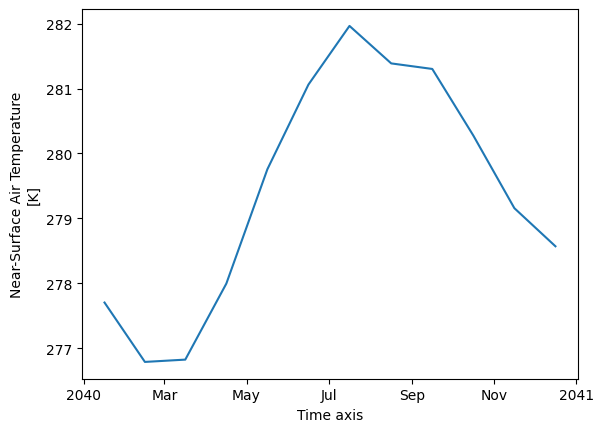

In [15]:
# ds['tas'].isel(time=slice(0,100)).mean(dim=('lat','lon')).plot()
ds["tas"].isel(time=slice(0, 12)).mean(dim=("lat", "lon")).plot()